# PGC308A — Task II: Estimativa da Métrica de Serviço (Regressão Linear)

Estimar `DispFrames` (Y) a partir das estatísticas do servidor (X) com **regressão linear**.

- Split **70% treino** (2520) / **30% teste** (1080), amostragem aleatória uniforme
- Métrica de acurácia: **NMAE** (precisa ser < 15%)
- Estudo com subconjuntos de treino: 50, 500, 1000, 1500, 2520 observações

In [1]:
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from sklearn.linear_model import LinearRegression

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.config import FIGURES_DIR, RANDOM_STATE, RESULTS_DIR, TRAIN_SIZES
from src.data import feature_columns, load_trace, target_column
from src.labels import format_model_coefficients, rename_coefficient_table, rename_regression_results
from src.metrics import nmae
from src.splits import sample_training_subset, train_test_split_trace

FIGURES_DIR.mkdir(exist_ok=True)
RESULTS_DIR.mkdir(exist_ok=True)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 5)

In [2]:
df = load_trace()
features = feature_columns()
target = target_column()

train_df, test_df, x_train, y_train, x_test, y_test = train_test_split_trace(
    df, features, target
)

print(f"Treino: {len(train_df)} | Teste: {len(test_df)}")

Treino: 2520 | Teste: 1080


## 1. Modelo M — Regressão linear no conjunto de treino completo

In [3]:
model = LinearRegression()
model.fit(x_train, y_train)
y_pred = model.predict(x_test)

coefficients = format_model_coefficients(features, model.coef_, model.intercept_)

nmae_m = nmae(y_test, y_pred)
accurate = nmae_m < 0.15

resumo_m = pd.DataFrame(
    {
        "Métrica": ["NMAE (%)", "Acurado (< 15%)?"],
        "Valor": [round(nmae_m * 100, 4), "Sim" if accurate else "Não"],
        "Significado": [
            "Erro médio absoluto normalizado entre valores medidos e estimados no teste",
            "Indica se o modelo M atende ao critério de acurácia exigido no enunciado",
        ],
    }
)

print(f"NMAE = {nmae_m:.4%}  |  Acurado (< 15%)? {'Sim' if accurate else 'Não'}")
display(resumo_m)
coefficients.round(6)

NMAE = 10.3877%  |  Acurado (< 15%)? Sim


,Métrica,Valor,Significado
0,NMAE (%),10.3877,Erro médio absoluto normalizado entre valores ...
1,Acurado (< 15%)?,Sim,Indica se o modelo M atende ao critério de acu...


,Variável,Coeficiente (Θ)
0,CPU ociosa (%),-0.092133
1,Memória usada (%),-0.086789
2,Taxa de criação de processos (/s),-0.011961
3,Taxa de troca de contexto (/s),-0.000097
4,File handles em uso,-0.003088
5,Taxa de interrupções (/s),0.000025
6,Média de carga — 1 min,-0.060592
7,Sockets TCP em uso,-0.065342
8,Taxa de liberação de páginas (/s),-0.000020
9,Intercepto (Θ₀),49.687811


### 1(c–e) Gráficos no conjunto de teste

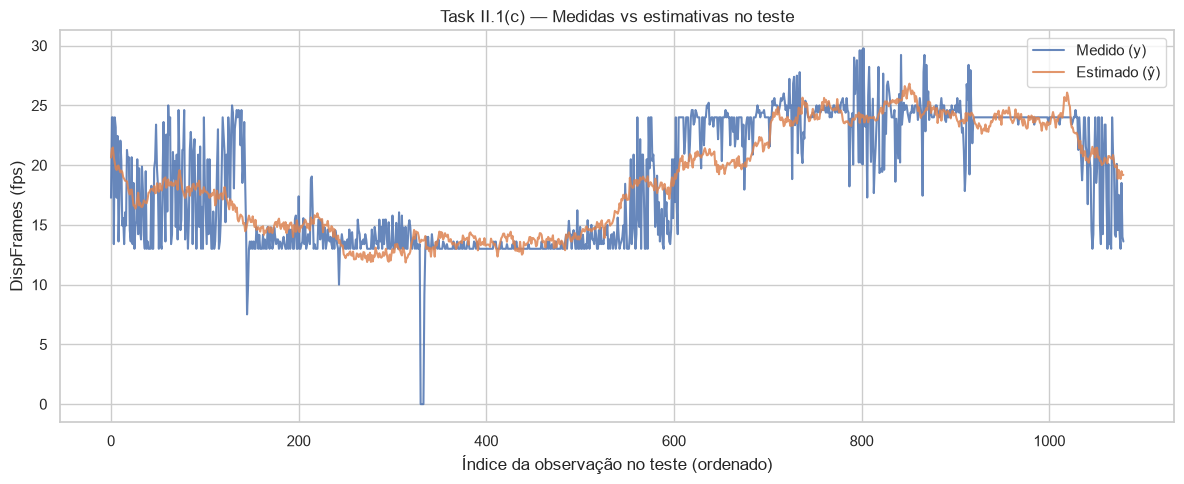

In [4]:
# Ordenar pelo índice original para série temporal
test_sorted = test_df.sort_index()
y_test_sorted = test_sorted[target].to_numpy()
y_pred_sorted = model.predict(test_sorted[features].to_numpy())

fig, ax = plt.subplots()
ax.plot(y_test_sorted, label="Medido (y)", alpha=0.85)
ax.plot(y_pred_sorted, label="Estimado (ŷ)", alpha=0.85)
ax.set_xlabel("Índice da observação no teste (ordenado)")
ax.set_ylabel("DispFrames (fps)")
ax.set_title("Task II.1(c) — Medidas vs estimativas no teste")
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES_DIR / "task_ii_1c_timeseries_test.png", dpi=150)
plt.show()

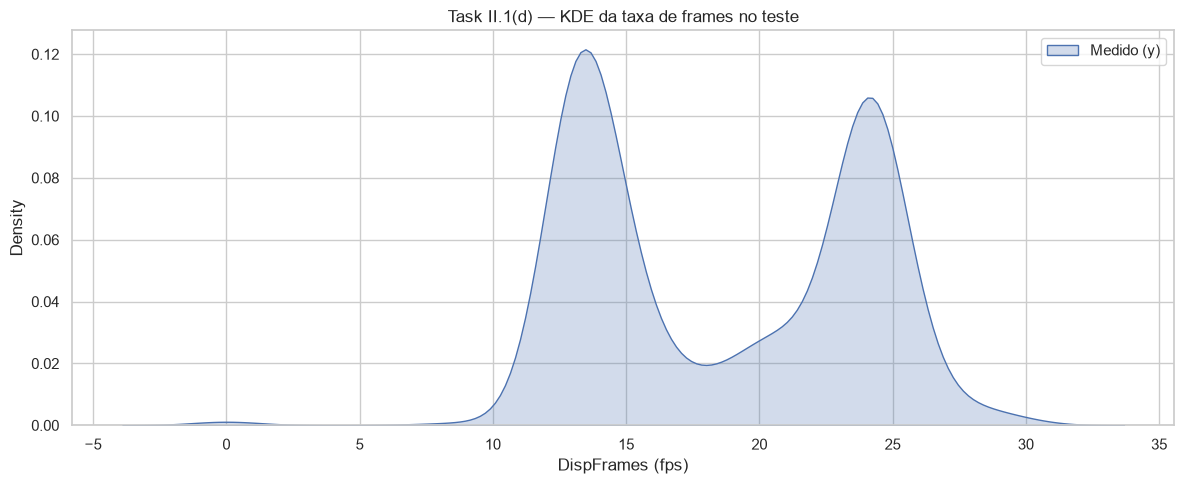

In [5]:
fig, ax = plt.subplots()
sns.kdeplot(y_test, ax=ax, fill=True, label="Medido (y)")
ax.set_xlabel("DispFrames (fps)")
ax.set_title("Task II.1(d) — KDE da taxa de frames no teste")
ax.legend()
fig.tight_layout()
fig.savefig(FIGURES_DIR / "task_ii_1d_kde_dispframes_test.png", dpi=150)
plt.show()

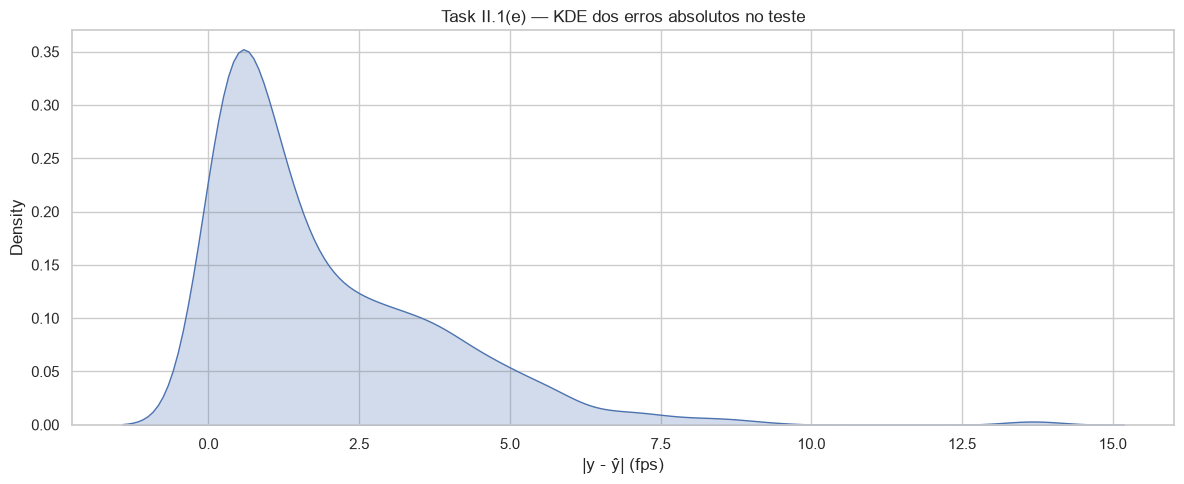

In [6]:
abs_errors = np.abs(y_test - y_pred)

fig, ax = plt.subplots()
sns.kdeplot(abs_errors, ax=ax, fill=True)
ax.set_xlabel("|y - ŷ| (fps)")
ax.set_title("Task II.1(e) — KDE dos erros absolutos no teste")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "task_ii_1e_kde_abs_errors.png", dpi=150)
plt.show()

## 2. Impacto do tamanho do conjunto de treino

Treinar modelos M₁…M₅ com 50, 500, 1000, 1500 e 2520 observações (amostradas do treino).

In [7]:
def train_and_evaluate(n_train: int) -> dict:
    subset = sample_training_subset(train_df, n_train, random_state=RANDOM_STATE)
    x_sub = subset[features].to_numpy()
    y_sub = subset[target].to_numpy()

    reg = LinearRegression()
    t0 = time.perf_counter()
    reg.fit(x_sub, y_sub)
    train_ms = (time.perf_counter() - t0) * 1000

    y_hat = reg.predict(x_test)
    return {
        "n_train": n_train,
        "model": reg,
        "coefficients": reg.coef_,
        "intercept": reg.intercept_,
        "train_time_ms": train_ms,
        "nmae": nmae(y_test, y_hat),
    }


results = [train_and_evaluate(n) for n in TRAIN_SIZES]
results_df = pd.DataFrame([
    {
        "n_train": r["n_train"],
        "train_time_ms": r["train_time_ms"],
        "nmae": r["nmae"],
        "nmae_pct": r["nmae"] * 100,
        "accurate": r["nmae"] < 0.15,
    }
    for r in results
])

rename_regression_results(results_df).round(4)

,Observações no treino,Tempo de treino (ms),NMAE (proporção),NMAE (%),Acurado (< 15%)?
0,50,1.1286,0.1152,11.5182,Sim
1,500,1.8649,0.1058,10.5750,Sim
2,1000,1.1853,0.1049,10.4925,Sim
3,1500,1.2246,0.1038,10.3776,Sim
4,2520,2.5865,0.1039,10.3877,Sim


In [8]:
coef_rows = []
for r in results:
    row = {"n_train": r["n_train"]}
    for feat, coef in zip(features, r["coefficients"]):
        row[feat] = coef
    row["intercept"] = r["intercept"]
    coef_rows.append(row)

coef_table = pd.DataFrame(coef_rows).set_index("n_train")
rename_coefficient_table(coef_table).round(6)

,CPU ociosa (%),Memória usada (%),Taxa de criação de processos (/s),Taxa de troca de contexto (/s),File handles em uso,Taxa de interrupções (/s),Média de carga — 1 min,Sockets TCP em uso,Taxa de liberação de páginas (/s),Intercepto (Θ₀)
Observações no treino,,,,,,,,,,
50,-0.038251,0.026317,-0.049736,-0.000016,-0.006633,0.000109,-0.044428,-0.044057,0.000027,36.838626
500,-0.100423,-0.061129,-0.033627,-0.000094,-0.002503,0.000028,-0.071084,-0.039191,-0.000016,45.032996
1000,-0.078881,-0.100634,-0.018320,-0.000078,-0.004386,0.000057,-0.059254,-0.060908,-0.000019,52.250307
1500,-0.088353,-0.078962,-0.011372,-0.000091,-0.003737,0.000036,-0.056535,-0.069753,-0.000017,49.797572
2520,-0.092133,-0.086789,-0.011961,-0.000097,-0.003088,0.000025,-0.060592,-0.065342,-0.000020,49.687811


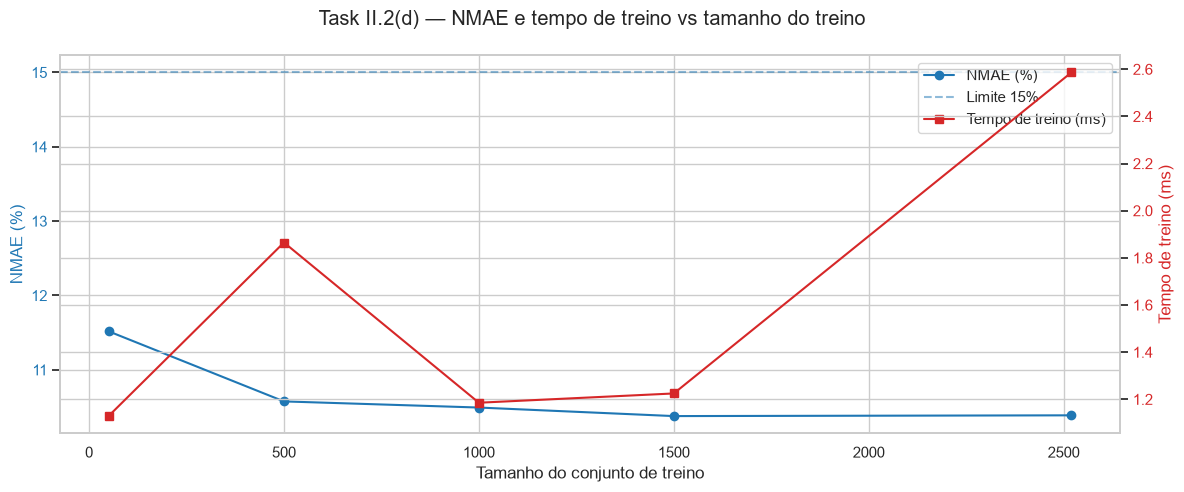

In [9]:
fig, ax1 = plt.subplots()

color_nmae = "tab:blue"
color_time = "tab:red"

ax1.plot(results_df["n_train"], results_df["nmae_pct"], "o-", color=color_nmae, label="NMAE (%)")
ax1.axhline(15, color=color_nmae, linestyle="--", alpha=0.5, label="Limite 15%")
ax1.set_xlabel("Tamanho do conjunto de treino")
ax1.set_ylabel("NMAE (%)", color=color_nmae)
ax1.tick_params(axis="y", labelcolor=color_nmae)

ax2 = ax1.twinx()
ax2.plot(results_df["n_train"], results_df["train_time_ms"], "s-", color=color_time, label="Tempo de treino (ms)")
ax2.set_ylabel("Tempo de treino (ms)", color=color_time)
ax2.tick_params(axis="y", labelcolor=color_time)

fig.suptitle("Task II.2(d) — NMAE e tempo de treino vs tamanho do treino")
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")
fig.tight_layout()
fig.savefig(FIGURES_DIR / "task_ii_2d_nmae_train_time.png", dpi=150)
plt.show()

In [10]:
rename_regression_results(results_df).round(4).to_csv(
    RESULTS_DIR / "task_ii_results.csv", index=False
)
rename_coefficient_table(coef_table).round(6).to_csv(RESULTS_DIR / "task_ii_coefficients.csv")
coefficients.round(6).to_csv(RESULTS_DIR / "task_ii_model_M_coefficients.csv", index=False)

print("Resultados salvos em results/")

Resultados salvos em results/
